# Final Evaluation & Compression Analysis (Task 4)

Loads the three best checkpoints produced by Notebooks 01–03 and builds the required comparison table: ResNet34 Teacher (FP32) vs. ResNet18 Baseline (FP32, no KD) vs. Ternary ResNet18 Student (KD+QAT).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


In [2]:
from src.data import get_cifar10_loaders, get_train_eval_loader

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)
train_eval_loader = get_train_eval_loader(data_dir="../data", batch_size=256)


In [3]:
from src.resnet_cifar import resnet34_cifar, resnet18_cifar
from src.ternary import TernaryConv2d, TernaryLinear
from src.config import TeacherConfig, BaselineConfig, StudentKDQATConfig

teacher = resnet34_cifar(num_classes=10)
teacher.load_state_dict(torch.load(TeacherConfig().checkpoint_path, map_location=device)["model_state_dict"])
teacher.to(device)

baseline = resnet18_cifar(num_classes=10)
baseline.load_state_dict(torch.load(BaselineConfig().checkpoint_path, map_location=device)["model_state_dict"])
baseline.to(device)

student = resnet18_cifar(num_classes=10, conv_layer=TernaryConv2d,
                          linear_layer=TernaryLinear, first_last_fp32=True)
student.load_state_dict(torch.load(StudentKDQATConfig().checkpoint_path, map_location=device)["model_state_dict"])
student.to(device)

print("All three checkpoints loaded.")


All three checkpoints loaded.


## Comparison table
Train/val/test accuracy, generalization gap, parameter count, model size, sparsity, and compression ratio for all three models — see `src/evaluate.py` for exact definitions.

In [4]:
from src.evaluate import build_comparison_table

comparison_df = build_comparison_table(
    teacher, baseline, student, train_eval_loader, val_loader, test_loader, device
)
comparison_df.to_csv("results/comparison_table.csv", index=False)
comparison_df


,Model,Params (M),Train Acc (%),Val Acc (%),Test Acc (%),Train-Test Gap (pp),Model Size (MB),Zero-Weight Sparsity (%),Compression vs Teacher (x),Compression vs FP32 ResNet18 (x)
0,ResNet34 Teacher (FP32),21.282,99.55,95.50,94.98,4.57,81.185,0.00,1.00,0.53
1,"ResNet18 Baseline (FP32, no KD)",11.174,99.56,95.56,95.08,4.48,42.625,0.00,1.90,1.00
2,ResNet18 Ternary Student (KD+QAT),11.174,99.49,95.10,94.63,4.86,2.741,47.69,29.62,15.55


## Accuracy comparison plot

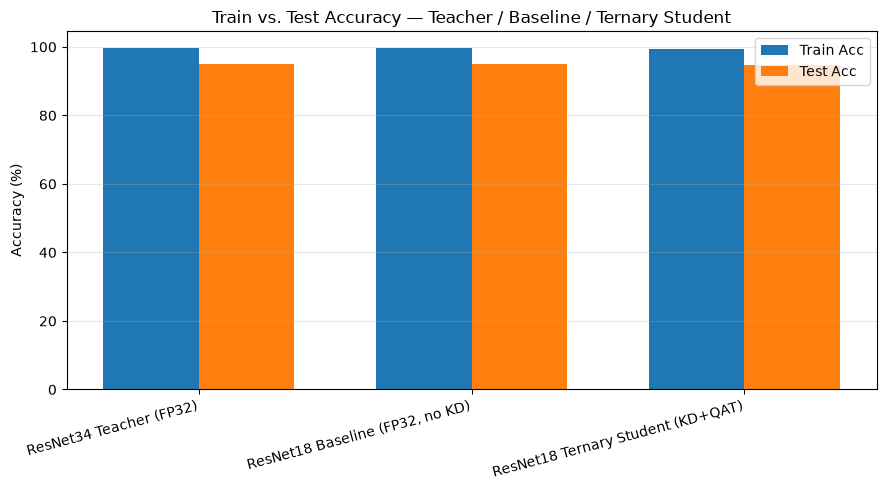

In [5]:
import matplotlib.pyplot as plt
import numpy as np

labels = comparison_df["Model"]
train_acc = comparison_df["Train Acc (%)"]
test_acc = comparison_df["Test Acc (%)"]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_acc, width, label="Train Acc")
ax.bar(x + width/2, test_acc, width, label="Test Acc")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs. Test Accuracy — Teacher / Baseline / Ternary Student")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("results/accuracy_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()


## Model size / compression plot

**Caveat (state this in the report):** the plotted sizes are *theoretical storage* figures (2 bits/ternary weight + per-channel FP32 scale). They are not a measured or implied inference-latency speedup — that requires specialized bit-packed kernels or dedicated hardware, which this project does not implement.

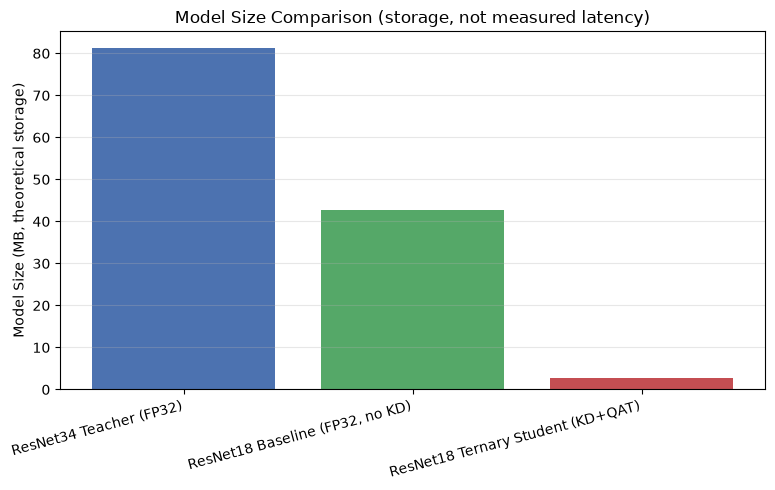

                            Model  Model Size (MB)  Compression vs Teacher (x)  Compression vs FP32 ResNet18 (x)  Zero-Weight Sparsity (%)
          ResNet34 Teacher (FP32)           81.185                        1.00                              0.53                      0.00
  ResNet18 Baseline (FP32, no KD)           42.625                        1.90                              1.00                      0.00
ResNet18 Ternary Student (KD+QAT)            2.741                       29.62                             15.55                     47.69


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison_df["Model"], comparison_df["Model Size (MB)"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Model Size (MB, theoretical storage)")
ax.set_title("Model Size Comparison (storage, not measured latency)")
plt.xticks(rotation=15, ha="right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("results/model_size_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(comparison_df[["Model", "Model Size (MB)",
                      "Compression vs Teacher (x)",
                      "Compression vs FP32 ResNet18 (x)",
                      "Zero-Weight Sparsity (%)"]].to_string(index=False))


## Checkpoint verification (re-confirmation)
Re-runs the ternary-constraint check on the loaded student checkpoint as a final sanity confirmation before writing the report.

In [7]:
from src.evaluate import checkpoint_verification_report

verification_df = checkpoint_verification_report(student)
print(verification_df.to_string(index=False))
print("\nAll layers satisfy the ternary constraint:",
      verification_df["Satisfies ternary constraint"].all())


                Layer  Satisfies ternary constraint
       layer1.0.conv1                          True
       layer1.0.conv2                          True
       layer1.1.conv1                          True
       layer1.1.conv2                          True
       layer2.0.conv1                          True
       layer2.0.conv2                          True
layer2.0.downsample.0                          True
       layer2.1.conv1                          True
       layer2.1.conv2                          True
       layer3.0.conv1                          True
       layer3.0.conv2                          True
layer3.0.downsample.0                          True
       layer3.1.conv1                          True
       layer3.1.conv2                          True
       layer4.0.conv1                          True
       layer4.0.conv2                          True
layer4.0.downsample.0                          True
       layer4.1.conv1                          True
       layer